# 309.3. Extendedness parameter

<div style="max-width:300px; float: left; margin-right: 1em">

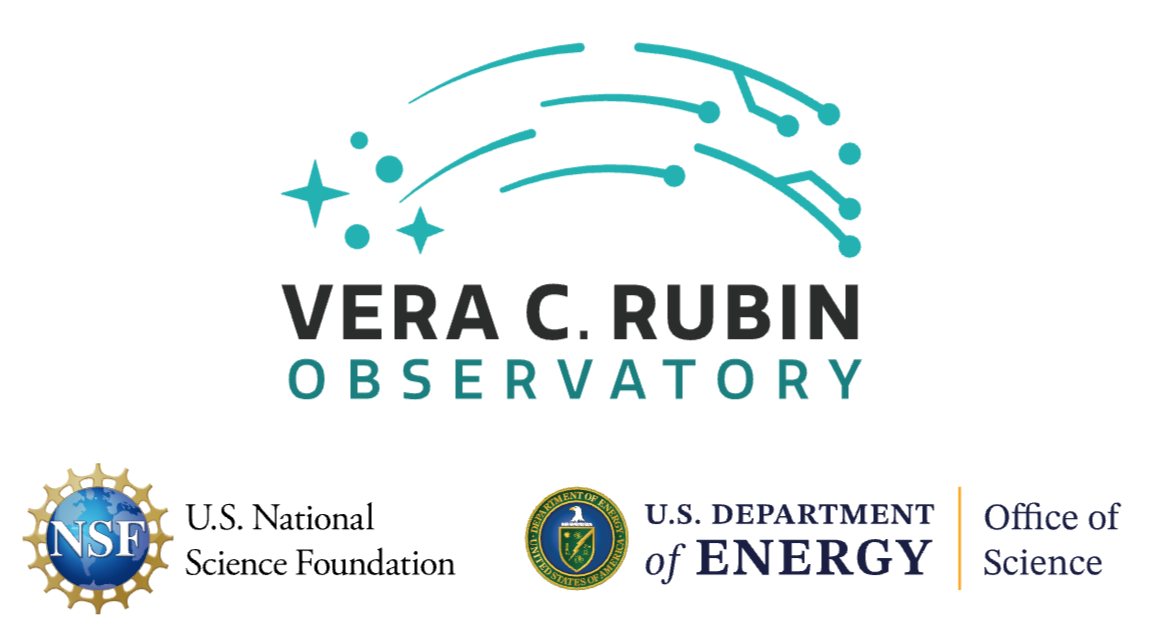

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 1](https://dp1.lsst.io)\
Container Size: large\
LSST Science Pipelines version: r29.2.0\
Last verified to run: 2026-04-07\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** To explore the extendedness parameter.

**LSST data products:** `Object`

**Packages:** `lsst.rsp`

**Credit:**
Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

In astronomical imaging surveys like LSST, classifying sources as either point-like (stars) or extended (galaxies) is a fundamental step in data analysis. In Data Preview 1 (DP1), this classification is primarily handled by the `extendedness` parameter. This tutorial demonstrates how this parameter was computed and the specific caveats noted in the [RTN-095](https://rtn-095.lsst.io/) technical note.

The LSST Science Pipelines distinguish stars from galaxies by comparing two different flux measurements for every detected object:
- PSF Flux: The flux measured by fitting the Point Spread Function (PSF) model to the source. This model assumes the source is unresolved.
- CModel Flux: The flux measured by fitting a "Composite Model". This model allows for the source to be extended.

The classification logic relies on the ratio of these two fluxes. For a star, the object is unresolved, meaning the PSF flux captures the same amount of light as the composite model, and the ratio is close to unity. For a galaxy, the object is extended, so the PSF fit fails to capture flux in the wings, causing the PSF flux to be significantly lower than the CModel flux. The pipeline applies a configurable threshold to this ratio to assign a **binary** flag. If the ratio PSF Flux/CModel Flux measured with a free centroid is greater than or equal to 0.985, the `extendedness` parameter is set to 0, indicating a star. Conversely, if the ratio is less than 0.985, the parameter is set to 1, indicating a galaxy.

However, users must be aware of critical limitations in the DP1 dataset as highlighted in RTN-095. The binary classification becomes unreliable at faint magnitudes (specifically $r$>24), where the "unresolved" sample suffers from increasing contamination by galaxies due to decreasing signal-to-noise ratios. Additionally, while the `Object` table provides `extendedness` values for every individual filter, it is strongly recommended to use `refExtendedness` for most science cases. This value is derived from the designated reference band (typically the band with the best seeing or depth), ensuring a single, robust classification for each object.

describe how the extendedness parameter (and any related flags) are computed
characterize the extendedness parameter
where it does well, where it fails, use color/color space and other object characteristics.

Nice things to add: extendedness parameters based on the flux ratio vs. 2nd moment shape parameter.

**Related tutorials:** 

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
(<a href="https://numpy.org">numpy.org</a>), 
and `matplotlib`, a comprehensive library for data visualization
(<a href="https://matplotlib.org/">matplotlib.org</a>;
<a href="https://matplotlib.org/stable/gallery/index.html">matplotlib gallery</a>).

From the LSST pacakge (<a href="https://pipelines.lsst.io/">pipelines.lsst.io</a>), import the RSP Table Access Protocol (TAP) service. Also import the `DustValues` class from the `rubin_sim` package (<a href="https://rubin-sim.lsst.io/index.html">rubin_sim</a>).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy import units as u
from astropy.coordinates import SkyCoord
import os

from lsst.rsp import get_tap_service
from rubin_sim.phot_utils import DustValues

### 1.2. Define parameters and functions

Create an instance of the TAP service, and assert that it exists.

In [4]:
rsp_tap = get_tap_service("tap")
assert rsp_tap is not None

Define a 1-degree radius around the central point of the 47 Tuc field.

In [133]:
ra_cen = 40.080
dec_cen = -34.450
radius = 1.0

List bands available in the field.

In [134]:
bands = "gri"

Set the environment variable `RUBIN_SIM_DATA_DIR` to `/rubin/rubin_sim_data` to make the current `rubin_sim` throughput data available.

In [135]:
os.environ['RUBIN_SIM_DATA_DIR'] = '/rubin/rubin_sim_data'

Set font sizes globally for all subsequent matplotlib figures in this notebook.

In [136]:
plt.rcParams["font.size"] = 15
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.titlesize"] = 12

## 2. Query `Object` table

The `Object` table contains forced photometric measurements on the deep coadded images at the locations of all objects detected with signal-to-noise ratio > 5 in a `deep_coadd` of any filter. 

Query the `Object` table for coordinates, photometric measurements (with free centroids), and extendedness parameter.

In [137]:
query = """
        SELECT coord_ra, coord_dec,
        g_psfMag, r_psfMag, i_psfMag,
        g_free_psfFlux, r_free_psfFlux, i_free_psfFlux,
        g_cModelMag, r_cModelMag, i_cModelMag,
        g_free_cModelFlux, r_free_cModelFlux, i_free_cModelFlux,
        g_extendedness, r_extendedness, i_extendedness,
        g_sizeExtendedness, r_sizeExtendedness, i_sizeExtendedness,
        refExtendedness, refSizeExtendedness, refBand
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), 
              CIRCLE('ICRS', {}, {}, {})) = 1
              AND g_free_psfFlux/g_free_psfFluxErr > 5
              AND r_free_psfFlux/r_free_psfFluxErr > 5
              AND i_free_psfFlux/i_free_psfFluxErr > 5
              AND g_free_cModelFlux/g_free_cModelFluxErr > 5
              AND r_free_cModelFlux/r_free_cModelFluxErr > 5
              AND i_free_cModelFlux/i_free_cModelFluxErr > 5
        """.format(ra_cen, dec_cen, radius)

In [138]:
job = rsp_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


Fetch the results and store them as a table.

In [139]:
assert job.phase == 'COMPLETED'
table = job.fetch_result().to_table()
print(f"The query returned {len(table)} objects.")

The query returned 74784 objects.


Option to display the table of results.

In [45]:
# table

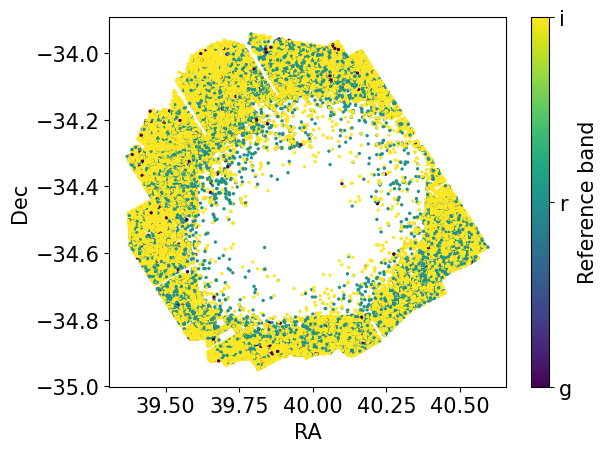

In [200]:
# A reference band is chosen for each object based on detection significance and measurement quality using a priority order (irzygu).

band_to_int = {'g': 0, 'r': 1, 'i': 2}
int_band = np.array([band_to_int.get(x, -1) for x in table['refBand']])
plt.scatter(table['coord_ra'], table['coord_dec'], c=int_band, s=2)
plt.xlabel('RA')
plt.ylabel('Dec')
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['g', 'r', 'i'])
cbar.set_label('Reference band')
plt.show()

## 3. Explore extendedness parameters

In the `Object` table, there are two types of extendedness parameters: one based on flux ratio and the other one based on size ratio. 

### 3.1 Flux-based extendedness

For a star, the object is unresolved, meaning the PSF flux captures the same amount of light as the composite model, and the ratio is close to unity. For a galaxy, the object is extended, so the PSF fit fails to capture flux in the wings, causing the PSF flux to be significantly lower than the cModel flux. The pipeline applies a configurable threshold to this ratio to assign a binary flag. If the ratio PSF Flux/cModel Flux is greater than or equal to 0.985, the `extendedness` parameter is set to 0, indicating a star. Conversely, if the ratio is less than 0.985, the parameter is set to 1, indicating a galaxy.

#### 3.1.1 Extendedness vs. flux ratio

Distribution of the ratio of PSF flux to cModel flux for objects classified as point sources versus extended sources in each $gri$ band. 

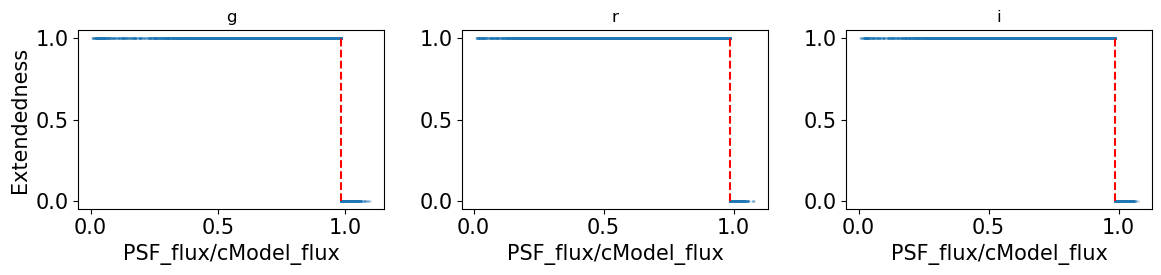

In [140]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    ax.scatter(table[f'{band}_free_psfFlux']/table[f'{band}_free_cModelFlux'],
               table[f'{band}_extendedness'], s=1, alpha=0.2)
    ax.plot([0.985, 0.985], [0, 1], 'r--')
    ax.set_title(f'{band}')
    ax.set_xlabel('PSF_flux/cModel_flux')
    if band == 'g':
        ax.set_ylabel('Extendedness')
    
plt.tight_layout()
plt.show()

> **Figure 1:** Distribution of the ratio between PSF flux and cModel flux for $g,r,i$ bands. The vertical red dashed line at 0.985 denotes the threshold used for morphological classification: sources with a ratio $\ge$0.985 are classified as point-like (`extendedness` = 0), while those below this value are classified as extended (`extendedness` = 1).

#### 3.1.2. Comparison with `refExtendedness`

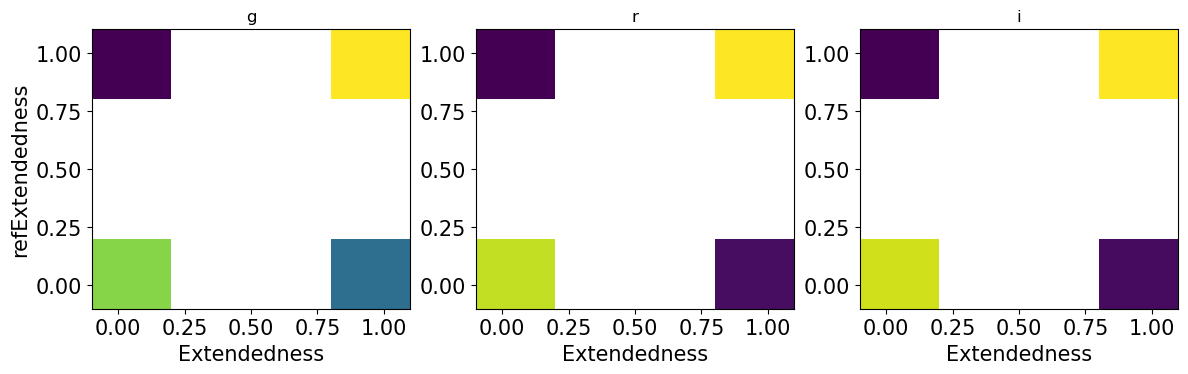

In [160]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))

for band, ax in zip(bands, axes.flatten()):
    ax.hist2d(table[f'{band}_extendedness'],
              table['refExtendedness'], bins=4, range=((-0.1, 1.1), (-0.1, 1.1)), norm=LogNorm())
    # ax.plot([0.985, 0.985], [0, 1], 'r--')
    ax.set_title(f'{band}')
    ax.set_xlabel('Extendedness')
    if band == 'g':
        ax.set_ylabel('refExtendedness')
    
plt.tight_layout()
plt.show()

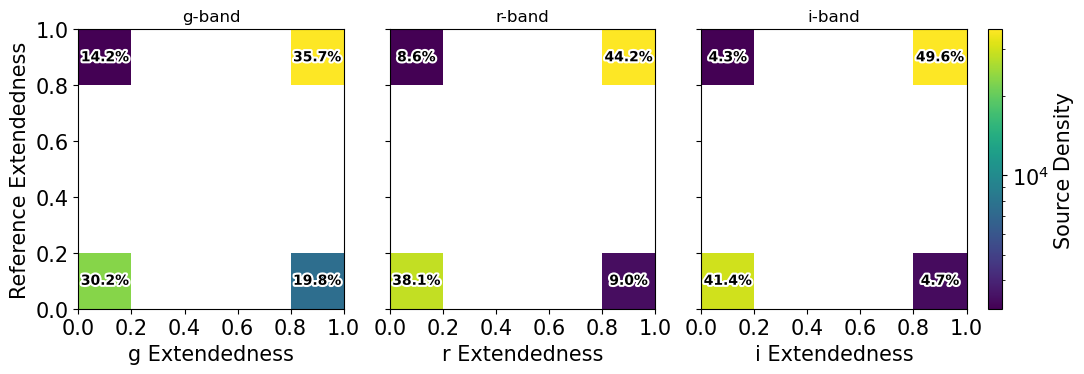

In [205]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
bin_edges = np.linspace(0, 1, 6)

for band, ax in zip(bands, axes):
    x = table[f'{band}_extendedness']
    y = table['refExtendedness']
    
    h, x_edges, y_edges, im = ax.hist2d(x, y, bins=bin_edges, 
                                        range=((0, 1), (0, 1)), 
                                        norm=LogNorm(), cmap='viridis')
    
    total = len(x.compressed()) if hasattr(x, 'mask') else len(x)
    
    for i in range(len(x_edges)-1):
        for j in range(len(y_edges)-1):
            count = h[i, j]
            if count > 0:
                pct = (count / total) * 100
                x_center = (x_edges[i] + x_edges[i+1]) / 2
                y_center = (y_edges[j] + y_edges[j+1]) / 2
                
                txt = ax.text(x_center, y_center, f'{pct:.1f}%', 
                              color='black', ha='center', va='center', 
                              fontsize=10, fontweight='bold')
                
                txt.set_path_effects([
                    path_effects.withStroke(linewidth=3, foreground='white')
                ])

    ax.set_title(f'{band}-band')
    ax.set_xlabel(f'{band} Extendedness')
    ax.set_xticks(bin_edges)
    ax.set_yticks(bin_edges)
    
    if band == 'g':
        ax.set_ylabel('Reference Extendedness')

plt.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label('Source Density')

plt.show()

#### 3.1.3. Brightness distribution of stars and galaxies

Explore the distribution of `extenededness` as a function of magnitude in each filter.

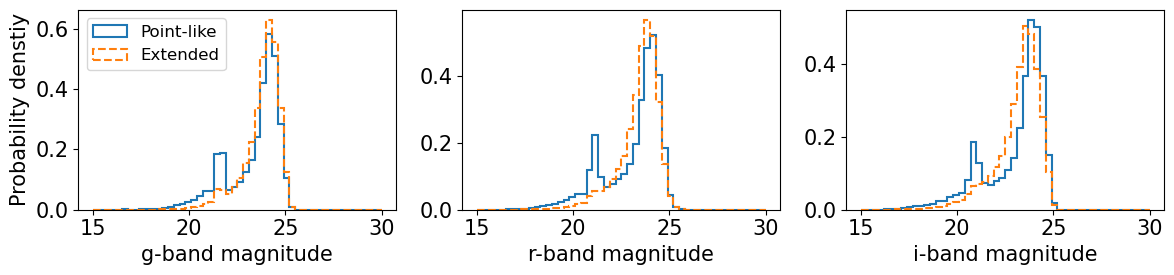

In [150]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    is_star = table[f'{band}_extendedness'] == 0
    
    ax.hist(table[f'{band}_psfMag'][is_star],
            bins=50, range=(15, 30), density=True,
            histtype='step', linewidth=1.5, label='Point-like'
    )
    
    ax.hist(table[f'{band}_cModelMag'][~is_star],
            bins=50, range=(15, 30), density=True,
            histtype='step', linestyle='--', linewidth=1.5, label='Extended'
    )

    ax.set_xlabel(f'{band}-band magnitude')
    
    if band == 'g':
        ax.set_ylabel('Probability denstiy')
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

> **Figure 2:** Magnitude distributions for point-like (blue solid lines) and extended (orange dashed lines) sources in the $g,r,i$ bands. Point sources are characterized by their `PSF` magnitudes, while extended sources use `cModel` magnitudes. The bump near 21 mag in the stellar distribution corresponds to red clump stars in the Fornax dSph.

### 3.2. Size-based extendedness

This parameter provides a continuous metric for star-galaxy separation by comparing the resolved size of an object to the local Point Spread Function (PSF). The classification relies on the "trace" of the adaptive moments matrix, defined as: $T=Ixx + Iyy$, where $Ixx$ and $Iyy$ are the second-order moments of the object's intensity distribution. $T$ serves as a robust, model-independent measure of the square of the radius. 

The $\chi^{2}$ statistic quantifies the extendedness by calculating the squared difference between the object's measured size and the expected PSF's size at the object's location, normalized by a power of the PSF size. This ensures the deviation is scaled appropriately relative to the local image quality.

The output is mapped onto a scale from 0 to 1, representing the probability of being a galaxy: {band}_`sizeExtendedness` $= 1 - e^{-0.5\chi^{2}}$. Values near 0 indicates the object's size is consistent with the PSF (likely a star), while values near 1 signifies the object is significantly more extended than the PSF (likely a galaxy).

#### 3.2.1. Distribution of `sizeExtendedness`

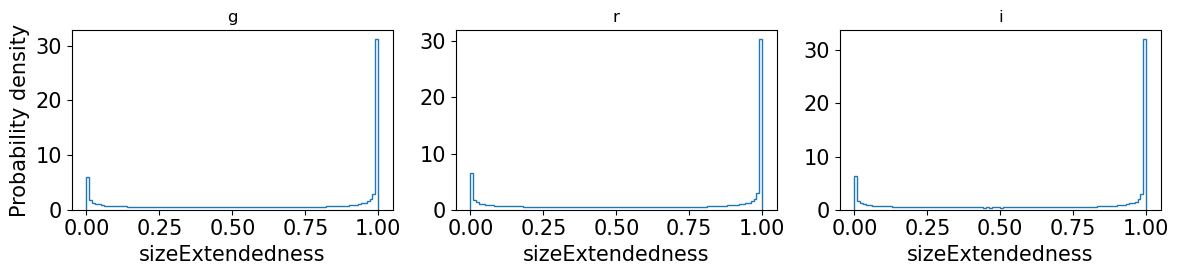

In [110]:
fig, axes = plt.subplots(1,3, figsize=(12, 3))

for band, ax in zip(bands, axes.flatten()):
    ax.hist(table[f'{band}_sizeExtendedness'], 
            bins=100, density=True, histtype='step'
    )
    ax.set_title(f'{band}')
    ax.set_xlabel(f'sizeExtendedness')
        
    if band == 'g':
        ax.set_ylabel('Probability density')

plt.tight_layout()
plt.show()

> **Figure 3:** In contrast to the binary, flux-based extendedness parameter, the `sizeExtendedness` parameter provides a continuous value ranging from 0 to 1, representing the degree of source extension.

#### 3.2.2. Comparison with `refSizeExtendedness`

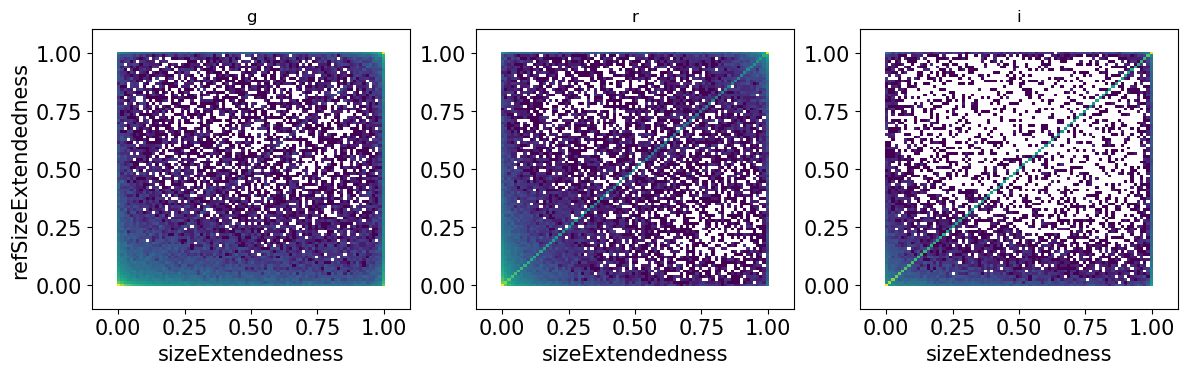

In [152]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))

for band, ax in zip(bands, axes.flatten()):
    ax.hist2d(table[f'{band}_sizeExtendedness'],
              table['refSizeExtendedness'], bins=100, range=((-0.1, 1.1), (-0.1, 1.1)), norm=LogNorm())
    # ax.plot([0.985, 0.985], [0, 1], 'r--')
    ax.set_title(f'{band}')
    ax.set_xlabel('sizeExtendedness')
    if band == 'g':
        ax.set_ylabel('refSizeExtendedness')
    
plt.tight_layout()
plt.show()

## 4. Extendedness vs. SizeExtendedness

Compare two different extendedness parameters. See how `SizeExtendedness` paramter was computed: https://github.com/lsst/meas_base/blob/main/python/lsst/meas/base/plugins.py#L683-L689.

**Slack conversation with Jim and Eli**
Jim: I voted against Eli on putting sizeExtendedness in object, because I don't think extendedness has really been tested all that much either, and I know it suffers from some garbage-in problems at the faint end.  It's been used for ages but nobody has done the work to say which is better.

Eli: But note that sizeExtendedness is a floating point value so you can adjust thresholds (unlike extendedness) sizeExtendedness is basically a likelihood measurement based on the HSM moments on the source and on the psf model, and comparing those. So if the HSM moment says that the source is similar in size to the PSF model at that location it has a higher likelihood of being a star.  And there’s an empirical scaling factor for seeing.

Jim: sizeExtendedness is measured the same way in both cases. flux-based extendedness is only potentially good for object. flux-based extendedness needs both a PSF flux input and a galaxy-model flux input.  We don't really run any galaxy modeling on the single-visit images, so any extendedness you see on source is from a poor substitute for a galaxy model flux.

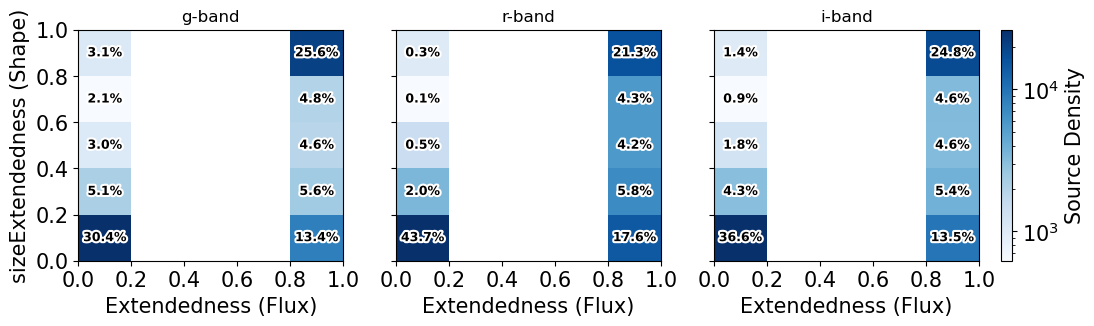

In [199]:
import matplotlib.patheffects as path_effects
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)

for band, ax in zip(bands, axes):
    x = table[f'{band}_extendedness']
    y = table[f'{band}_sizeExtendedness']
    
    # Define 5x5 bins over the 0 to 1 range
    # We use 6 edges to create 5 bins
    bin_edges = np.linspace(0, 1, 6)
    
    h, x_edges, y_edges, im = ax.hist2d(x, y, bins=bin_edges, 
                                        range=((0, 1), (0, 1)), 
                                        cmap='Blues', norm=LogNorm())
    
    # Calculate percentages
    total_sources = len(x.compressed()) if hasattr(x, 'mask') else len(x)
    percentages = (h / total_sources) * 100

    # Add text annotations to each grid cell
    for i in range(len(x_edges)-1):
        for j in range(len(y_edges)-1):
            if percentages[i,j] > 0:
                t = ax.text(x_edges[i] + 0.1, y_edges[j] + 0.1, f'{percentages[i,j]:.1f}%',
                            color='black', ha='center', va='center', fontsize=9, fontweight='bold')
                t.set_path_effects([
                path_effects.withStroke(linewidth=3, foreground='white')
                ])

    ax.set_title(f'{band}-band')
    ax.set_xlabel('Extendedness (Flux)')
    ax.set_xticks(bin_edges)
    ax.set_yticks(bin_edges)
    
    if band == 'g':
        ax.set_ylabel('sizeExtendedness (Shape)')

# Add common colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label('Source Density')

plt.show()

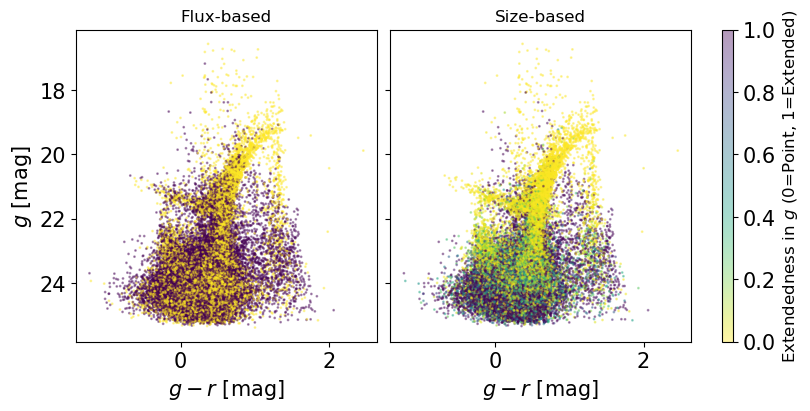

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, constrained_layout=True)

titles = ['Flux-based', 'Size-based']
col_vals = [table['g_extendedness'], table['g_sizeExtendedness']]
for i, ax in enumerate(axes):
    sc = ax.scatter(table['g_psfMag'] - table['r_psfMag'],
                    table['g_psfMag'], c=col_vals[i], 
                    s=1, cmap='viridis_r', alpha=0.4, vmin=0, vmax=1)
    
    ax.set_title(titles[i])
    ax.set_xlabel('$g - r$ [mag]')
    
    if i == 0:
        ax.set_ylabel('$g$ [mag]')
        ax.invert_yaxis()

cbar = fig.colorbar(sc, ax=axes, location='right', aspect=30)
cbar.set_label('Extendedness in $g$ (0=Point, 1=Extended)', fontsize=12)

plt.show()